In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("market_data.db")
df = pd.read_sql("SELECT * FROM candles WHERE ticker='000660'", conn)
conn.close()

In [86]:
df

,ticker,timeframe,timestamp,open,high,low,close,volume
0,000660,1m,2026-07-23T10:01:00.000+09:00,1928000.0,1931000.0,1921000.0,1924000.0,16304.0
1,000660,1m,2026-07-23T10:02:00.000+09:00,1924000.0,1928000.0,1921000.0,1925000.0,13936.0
2,000660,1m,2026-07-23T10:03:00.000+09:00,1925000.0,1931000.0,1925000.0,1930000.0,12155.0
3,000660,1m,2026-07-23T10:04:00.000+09:00,1930000.0,1936000.0,1925000.0,1935000.0,46968.0
4,000660,1m,2026-07-23T10:05:00.000+09:00,1936000.0,1938000.0,1933000.0,1936000.0,23329.0
...,...,...,...,...,...,...,...,...
14995,000660,1m,2026-08-21T19:56:00.000+09:00,1763000.0,1764000.0,1761000.0,1761000.0,7178.0
14996,000660,1m,2026-08-21T19:57:00.000+09:00,1761000.0,1762000.0,1759000.0,1759000.0,6718.0
14997,000660,1m,2026-08-21T19:58:00.000+09:00,1759000.0,1760000.0,1758000.0,1758000.0,7721.0
14998,000660,1m,2026-08-21T19:59:00.000+09:00,1759000.0,1760000.0,1758000.0,1759000.0,11933.0


In [87]:
import numpy as np
import pandas as pd
import xlwings as xw
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# df = pd.read_excel("C:\\Users\\sungwon\\Desktop\\orchestra.xlsm", sheet_name="SKHynix")
df = df.rename(columns={
    "TimeStamp": "timestamp",
    "Open": "open",
    "Close": "close",
    "High": "high",
    "Low": "low",
    "Volume": "volume"
})

In [88]:
df

,ticker,timeframe,timestamp,open,high,low,close,volume
0,000660,1m,2026-07-23T10:01:00.000+09:00,1928000.0,1931000.0,1921000.0,1924000.0,16304.0
1,000660,1m,2026-07-23T10:02:00.000+09:00,1924000.0,1928000.0,1921000.0,1925000.0,13936.0
2,000660,1m,2026-07-23T10:03:00.000+09:00,1925000.0,1931000.0,1925000.0,1930000.0,12155.0
3,000660,1m,2026-07-23T10:04:00.000+09:00,1930000.0,1936000.0,1925000.0,1935000.0,46968.0
4,000660,1m,2026-07-23T10:05:00.000+09:00,1936000.0,1938000.0,1933000.0,1936000.0,23329.0
...,...,...,...,...,...,...,...,...
14995,000660,1m,2026-08-21T19:56:00.000+09:00,1763000.0,1764000.0,1761000.0,1761000.0,7178.0
14996,000660,1m,2026-08-21T19:57:00.000+09:00,1761000.0,1762000.0,1759000.0,1759000.0,6718.0
14997,000660,1m,2026-08-21T19:58:00.000+09:00,1759000.0,1760000.0,1758000.0,1758000.0,7721.0
14998,000660,1m,2026-08-21T19:59:00.000+09:00,1759000.0,1760000.0,1758000.0,1759000.0,11933.0


In [89]:
BUY_SLIPPAGE = 0.00015
SELL_SLIPPAGE = 0.00215

TRAIN_RATIO = 0.7

In [90]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

<Axes: title={'center': '5-day SMA of Close Price'}>

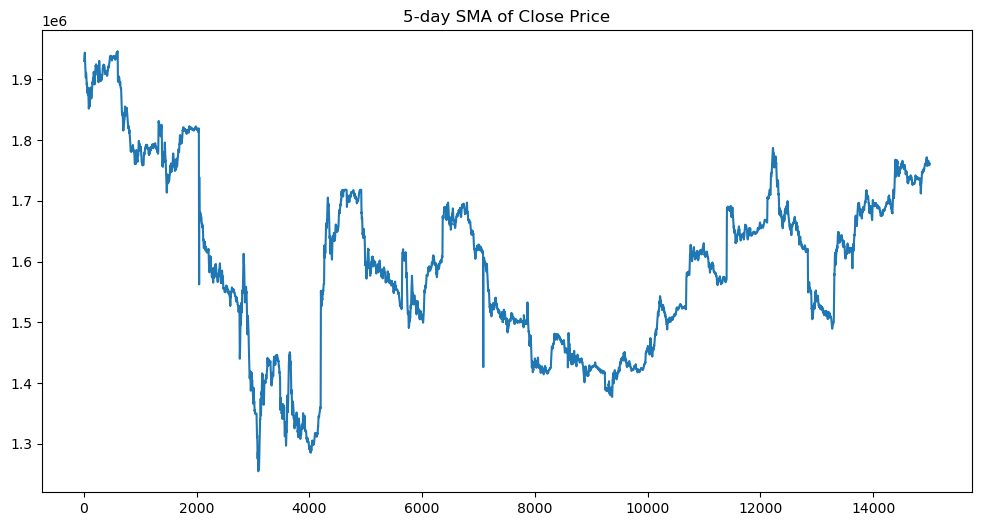

In [91]:
df['close'].rolling(5).mean().plot(x=df['timestamp'], title='5-day SMA of Close Price', figsize=(12, 6))

In [73]:
def add_sma(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["sma5"] = df["close"].rolling(5).mean()
    df["sma20"] = df["close"].rolling(20).mean()
    return df

In [74]:
# 여기서 lam은 lambda란 뜻이구나.
def add_ema(df: pd.DataFrame, lam: float) -> pd.DataFrame:
    df = df.copy()
    df["ema5"] = df["close"].ewm(alpha=lam, adjust=False).mean()
    return df

In [75]:
def backtest(df: pd.DataFrame, lam: float, buy_slip: float = BUY_SLIPPAGE, sell_slip: float = SELL_SLIPPAGE) -> pd.DataFrame:
    d = add_ema(df, lam)
    d = add_sma(d)
    d = d.dropna(subset=["sma5", "sma20", "ema5"]).reset_index(drop=True)
 
    holding = False
    entry_price = None
    entry_idx = None
    trades = []
    total_return = 0.0
 
    for i in range(1, len(d)):
        if not holding:
            golden_cross = (d["sma5"].iloc[i] > d["sma20"].iloc[i]) and \
                           (d["sma5"].iloc[i - 1] <= d["sma20"].iloc[i - 1])
            if golden_cross:
                entry_price = d["close"].iloc[i] * (1 + buy_slip)
                entry_idx = i
                holding = True
        else:
            if i > entry_idx and d["sma5"].iloc[i] > d["ema5"].iloc[i]:
                exit_price = d["close"].iloc[i] * (1 - sell_slip)
                trade_return = exit_price - entry_price
                total_return = total_return + trade_return
                trades.append({
                    "entry_date": d["timestamp"].iloc[entry_idx],
                    "exit_date": d["timestamp"].iloc[i],
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "return": trade_return
                })
                holding = False
 
    return total_return, pd.DataFrame(trades)

In [76]:
def optimize_lambda(df: pd.DataFrame, buy_slip=BUY_SLIPPAGE, sell_slip=SELL_SLIPPAGE,
                     coarse_step: float = 0.01):
    lambdas = np.arange(0.01, 1.00, coarse_step)
    results = []
    for lam in lambdas:
        r, _ = backtest(df, lam, buy_slip, sell_slip)
        results.append({"lambda": lam, "total_return": r})
    results_df = pd.DataFrame(results)
 
    best_coarse = results_df.loc[results_df["total_return"].idxmax()]
    best_lam_coarse = best_coarse["lambda"]
 
    # coarse 최적점 주변에서 정밀 탐색
    lo = max(0.001, best_lam_coarse - coarse_step)
    hi = min(0.999, best_lam_coarse + coarse_step)
 
    def neg_return(lam):
        r, _ = backtest(df, lam, buy_slip, sell_slip)
        return -r
 
    res = minimize_scalar(neg_return, bounds=(lo, hi), method="bounded")
    best_lambda = res.x
    best_return = -res.fun
 
    return best_lambda, best_return, results_df

In [77]:
def walk_forward_validate(df: pd.DataFrame, train_ratio: float = TRAIN_RATIO):
    split_idx = int(len(df) * train_ratio)
    train_df = df.iloc[:split_idx].reset_index(drop=True)
    test_df = df.iloc[split_idx:].reset_index(drop=True)
 
    best_lambda, train_return, results_df = optimize_lambda(train_df)
    test_return, test_trades = backtest(test_df, best_lambda)
 
    # buy & hold 비교 (test 구간)
    bh_return = test_df["close"].iloc[-1] - test_df["close"].iloc[0]
 
    return {
        "best_lambda": best_lambda,
        "train_return": train_return,
        "test_return": test_return,
        "test_trades": test_trades,
        "buyhold_return": bh_return,
        "lambda_scan": results_df,
        "train_df": train_df,
        "test_df": test_df,
    }
 

In [78]:
def plot_lambda_curve(results_df: pd.DataFrame, best_lambda: float, save_path: str):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["lambda"], results_df["total_return"] * 100, linewidth=1.5)
    plt.axvline(best_lambda, color="red", linestyle="--", label=f"best lambda={best_lambda:.3f}")
    plt.xlabel("lambda (EMA smoothing factor)")
    plt.ylabel("Cumulative Return (%)")
    plt.title("Cumulative Return vs Lambda (train period)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.close()

In [92]:
def main(df: pd.DataFrame):
    results = walk_forward_validate(df)
 
    print(f"결과")
    print(f"      최적 λ (train)   : {results['best_lambda']:.4f}")
    print(f"      Train 누적수익률 : {results['train_return']:.0f}")
    print(f"      Test 누적수익률  : {results['test_return']:.0f}")
    print(f"      Test Buy&Hold    : {results['buyhold_return']:.0f}")
    print(f"      Test 거래횟수    : {len(results['test_trades'])}")
 
    print("그래프 저장 및 엑셀 기록 중...")
    plot_lambda_curve(results["lambda_scan"], results["best_lambda"], "lambda_curve.png")

In [93]:
main(df)

결과
      최적 λ (train)   : 0.0206
      Train 누적수익률 : -769724
      Test 누적수익률  : -412747
      Test Buy&Hold    : 245000
      Test 거래횟수    : 96
그래프 저장 및 엑셀 기록 중...
